In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from IPython.display import display

pd.set_option('display.width', 160)

FOLDER = next(p for p in [Path('logistical_regression_analysis'), Path('.')] if (p / 'clean_data.csv').exists())
clean = pd.read_csv(FOLDER / 'clean_data.csv')
print('Loaded clean_data.csv:', clean.shape)

# Analysis sample: people with both a treatment Z and an outcome Y.
# All three estimators and the propensity model use exactly this sample.
data = clean.dropna(subset=['Z', 'Y']).reset_index(drop=True)
print(f'Analysis sample: {len(data):,} people '
      f'(dropped {len(clean) - len(data):,} with Z or Y missing)')


Loaded clean_data.csv: (8984, 23)
Analysis sample: 8,467 people (dropped 517 with Z or Y missing)


`make_X` turns the cleaned covariates into the matrix used by every model:
1. **Missing values** are filled with the covariate's mean in the analysis sample.
2. **Continuous covariates are standardized**, so a propensity odds ratio means "per 1 standard deviation".
3. **Race** becomes 0/1 columns with White as the reference group. Asian is combined with Other here, because only 5 Asian respondents were victimized (1 in the Z = 0 group), too few for a separate coefficient in the outcome models.
4. **An intercept** is added.

Birth year is not a covariate.

In [2]:
CONTINUOUS = ['networth_10k', 'hh_size', 'mother_educ', 'father_educ', 'asvab', 'days_absent',
              'teachers_good', 'discipline_fair', 'threatened_school', 'fight_school',
              'peers_smoke', 'peers_drunk', 'peers_gang']
BINARY = ['female', 'hard_times', 'parent_prison', 'bullied_before_12', 'bullied_12_18', 'arrested_before_18']
# Race: White is the reference group. Asian is combined with Other in the models, because only 5 Asian
# respondents in the analysis sample were victimized (1 in the Z = 0 group), too few to estimate a
# separate coefficient. clean_data.csv keeps all five categories.
RACE_GROUPS = ['Black', 'Hispanic', 'Other']

def make_X(frame):
    """Covariate matrix X for the logistic regressions.
    1. Fill each missing value with that covariate's mean in `frame`.
    2. Standardize continuous covariates: (x - mean) / sd, so odds ratios are per 1 SD.
    3. Race as 0/1 columns (Asian combined with Other), with White as the reference group.
    4. Add an intercept column.
    """
    X = pd.DataFrame(index=frame.index)
    for col in CONTINUOUS:
        x = frame[col].fillna(frame[col].mean())
        X[col] = (x - x.mean()) / x.std()
    for col in BINARY:
        X[col] = frame[col].fillna(frame[col].mean())
    race = frame['race'].replace({'Asian': 'Other'})
    for group in RACE_GROUPS:
        X[f'race_{group}'] = (race == group).astype(float)
    return sm.add_constant(X)

X = make_X(data)
Z = data['Z'].to_numpy()
Y = data['Y'].to_numpy()
print('X has', X.shape[1] - 1, 'covariates plus an intercept')


X has 22 covariates plus an intercept


Z and Y

In [3]:
# A first look at Z and Y in the analysis sample.
counts = pd.crosstab(data['Z'].map({1.0: 'Z = 1', 0.0: 'Z = 0'}), data['Y'].map({1.0: 'Y = 1', 0.0: 'Y = 0'}),
                     margins=True, margins_name='Total')
display(counts)
rates = data.groupby('Z')['Y'].agg(people='size', victimized='sum', rate='mean')
rates['rate %'] = (100 * rates['rate']).round(2)
display(rates.drop(columns='rate'))

Y,Y = 0,Y = 1,Total
Z,,,
Z = 0,4193,287,4480
Z = 1,3754,233,3987
Total,7947,520,8467


,people,victimized,rate %
Z,,,
0.0,4480,287.0,6.41
1.0,3987,233.0,5.84


Propensity model: $\hat p(Z = 1 \mid X)$

In [4]:
# Propensity model: logistic regression of Z on X. p_hat = estimated P(Z = 1 | X) for each person.
ps_model = sm.Logit(Z, X).fit(disp=0)
print('Converged:', ps_model.mle_retvals['converged'], '| n =', int(ps_model.nobs))
p_hat = ps_model.predict(X).to_numpy()

odds_ratios = pd.DataFrame({'OR': np.exp(ps_model.params),
                            'CI low': np.exp(ps_model.conf_int()[0]),
                            'CI high': np.exp(ps_model.conf_int()[1]),
                            'p-value': ps_model.pvalues}).drop(index='const').round(3)
display(odds_ratios.sort_values('OR'))


Converged: True | n = 8467


,OR,CI low,CI high,p-value
arrested_before_18,0.411,0.356,0.474,0.000
hard_times,0.642,0.502,0.820,0.000
parent_prison,0.747,0.599,0.931,0.010
days_absent,0.768,0.716,0.823,0.000
bullied_12_18,0.830,0.702,0.981,0.029
teachers_good,0.862,0.817,0.911,0.000
bullied_before_12,0.886,0.779,1.007,0.064
peers_smoke,0.904,0.846,0.966,0.003
peers_gang,0.938,0.886,0.993,0.028
fight_school,0.961,0.899,1.027,0.242


Two checks:
- the largest weights;
- the average of $Z/\hat p$ and of $(1 - Z)/(1 - \hat p)$. With a reasonable propensity model, both should be close to 1.

p_hat ranges from 0.0003 to 0.9786
p_hat in [0, 0.05]: 87 people (4 with Z = 1, 83 with Z = 0)
p_hat in [0.95, 1]: 30 people (25 with Z = 1, 5 with Z = 0)
Largest weight: Z = 1 group 29.1, Z = 0 group 42.2
mean of Z/p_hat = 0.993   mean of (1-Z)/(1-p_hat) = 1.033


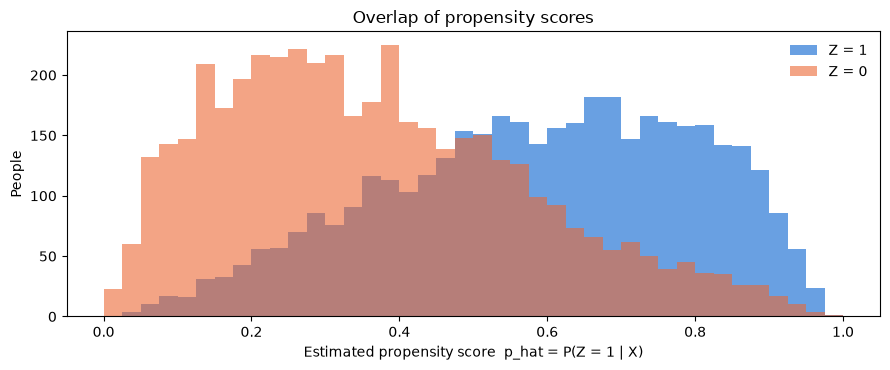

In [5]:
# Positivity check: p_hat must stay away from 0 and 1, because IPW and DR divide by p_hat and 1 - p_hat.
print(f'p_hat ranges from {p_hat.min():.4f} to {p_hat.max():.4f}')
for lo, hi in [(0, 0.05), (0.95, 1)]:
    in_range = (p_hat >= lo) & (p_hat <= hi)
    print(f'p_hat in [{lo}, {hi}]: {int(in_range.sum())} people '
          f'({int((in_range & (Z == 1)).sum())} with Z = 1, {int((in_range & (Z == 0)).sum())} with Z = 0)')

weight_treated = 1 / p_hat[Z == 1]          # IPW weight for each Z = 1 person
weight_control = 1 / (1 - p_hat[Z == 0])    # IPW weight for each Z = 0 person
print(f'Largest weight: Z = 1 group {weight_treated.max():.1f}, Z = 0 group {weight_control.max():.1f}')
# Check: the average of Z/p_hat and of (1-Z)/(1-p_hat) should both be close to 1.
print(f'mean of Z/p_hat = {np.mean(Z / p_hat):.3f}   mean of (1-Z)/(1-p_hat) = {np.mean((1 - Z) / (1 - p_hat)):.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.linspace(0, 1, 41)
ax.hist(p_hat[Z == 1], bins=bins, alpha=0.7, color='#2a78d6', label='Z = 1')
ax.hist(p_hat[Z == 0], bins=bins, alpha=0.6, color='#eb6834', label='Z = 0')
ax.set(xlabel='Estimated propensity score  p_hat = P(Z = 1 | X)', ylabel='People',
       title='Overlap of propensity scores')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


Outcome models: $\hat\mu_1(X)$ and $\hat\mu_0(X)$

In [6]:
# Outcome models (logistic regression), fit SEPARATELY in each treatment group:
#   mu1_hat(X) = P(Y = 1 | X, Z = 1), fit using only the Z = 1 people
#   mu0_hat(X) = P(Y = 1 | X, Z = 0), fit using only the Z = 0 people
# Then both are used to predict for EVERYONE in the analysis sample ("predict(lm, data = all)").
treated, control = Z == 1, Z == 0
mu1_model = sm.Logit(Y[treated], X[treated]).fit(disp=0)
mu0_model = sm.Logit(Y[control], X[control]).fit(disp=0)
for name, model, group in [('mu1_hat (Z = 1 people)', mu1_model, treated), ('mu0_hat (Z = 0 people)', mu0_model, control)]:
    print(f'{name}: n = {int(model.nobs):,}, victimized = {int(Y[group].sum())}, '
          f'converged = {model.mle_retvals["converged"]}')

mu1_hat = mu1_model.predict(X).to_numpy()   # everyone's predicted risk if they had Z = 1
mu0_hat = mu0_model.predict(X).to_numpy()   # everyone's predicted risk if they had Z = 0
print(f'Average predicted risk for everyone: mu1_hat {100 * mu1_hat.mean():.2f}%, mu0_hat {100 * mu0_hat.mean():.2f}%')


mu1_hat (Z = 1 people): n = 3,987, victimized = 233, converged = True
mu0_hat (Z = 0 people): n = 4,480, victimized = 287, converged = True
Average predicted risk for everyone: mu1_hat 5.96%, mu0_hat 6.22%


Three estimators

**Regression:**
$$\hat\tau_{reg} = \frac{1}{n}\sum_{i=1}^n \left[\hat\mu_1(X_i) - \hat\mu_0(X_i)\right]$$

**Inverse propensity weighting:**
$$\hat\tau_{IPW} = \frac{1}{n}\sum_{i=1}^n \left[\frac{Z_i Y_i}{\hat p(Z_i = 1 \mid X_i)} - \frac{(1 - Z_i) Y_i}{1 - \hat p(Z_i = 1 \mid X_i)}\right]$$

**Doubly robust:**
$$\hat\tau_{DR} = \frac{1}{n}\sum_{i=1}^n \left\{\left[\hat\mu_1(X_i) + \frac{Z_i\,(Y_i - \hat\mu_1(X_i))}{\hat p(Z_i = 1 \mid X_i)}\right] - \left[\hat\mu_0(X_i) + \frac{(1 - Z_i)\,(Y_i - \hat\mu_0(X_i))}{1 - \hat p(Z_i = 1 \mid X_i)}\right]\right\}$$

The table shows each estimator's $E[Y(1)]$, $E[Y(0)]$ and their difference, the ATE.

In [7]:
def regression_estimate(mu1_hat, mu0_hat):
    ey1, ey0 = np.mean(mu1_hat), np.mean(mu0_hat)
    return ey1, ey0, ey1 - ey0

def ipw_estimate(Z, Y, p_hat):
    ey1 = np.mean(Z * Y / p_hat)
    ey0 = np.mean((1 - Z) * Y / (1 - p_hat))
    return ey1, ey0, ey1 - ey0

def dr_estimate(Z, Y, p_hat, mu1_hat, mu0_hat):
    ey1 = np.mean(mu1_hat + Z * (Y - mu1_hat) / p_hat)
    ey0 = np.mean(mu0_hat + (1 - Z) * (Y - mu0_hat) / (1 - p_hat))
    return ey1, ey0, ey1 - ey0

estimates = pd.DataFrame(
    [regression_estimate(mu1_hat, mu0_hat), ipw_estimate(Z, Y, p_hat), dr_estimate(Z, Y, p_hat, mu1_hat, mu0_hat)],
    index=['Regression (tau_reg)', 'IPW (tau_IPW)', 'Doubly robust (tau_DR)'],
    columns=['E[Y(1)]', 'E[Y(0)]', 'ATE'])
display((100 * estimates).round(2).rename(columns=lambda c: c + ' (%)' if c != 'ATE' else 'ATE (percentage points)'))


,E[Y(1)] (%),E[Y(0)] (%),ATE (percentage points)
Regression (tau_reg),5.96,6.22,-0.25
IPW (tau_IPW),5.81,6.38,-0.57
Doubly robust (tau_DR),5.82,6.11,-0.29


Bootstrap confidence intervals

1. Draw n people from the analysis sample **with replacement**.
2. Redo every step on that sample: fill-in, propensity model, both outcome models and all three estimators.
3. Repeat 1,000 times.

In [8]:
def all_three_ates(frame):
    X_b = make_X(frame)
    Z_b, Y_b = frame['Z'].to_numpy(), frame['Y'].to_numpy()
    fits = [sm.Logit(Z_b, X_b).fit(disp=0),
            sm.Logit(Y_b[Z_b == 1], X_b[Z_b == 1]).fit(disp=0),
            sm.Logit(Y_b[Z_b == 0], X_b[Z_b == 0]).fit(disp=0)]
    converged = all(f.mle_retvals['converged'] for f in fits)
    p_b, mu1_b, mu0_b = [f.predict(X_b).to_numpy() for f in fits]
    return [regression_estimate(mu1_b, mu0_b)[2], ipw_estimate(Z_b, Y_b, p_b)[2],
            dr_estimate(Z_b, Y_b, p_b, mu1_b, mu0_b)[2]], converged

warnings.simplefilter('ignore', ConvergenceWarning)   # non-convergence is counted below instead of printed
B = 1000
rng = np.random.default_rng(36490)                 # fixed seed so the results repeat exactly
boot, n_not_converged = [], 0
for b in range(B):
    rows = rng.integers(0, len(data), len(data))   # draw n people with replacement
    ates, ok = all_three_ates(data.iloc[rows].reset_index(drop=True))
    if ok:
        boot.append(ates)
    else:
        n_not_converged += 1
boot = np.array(boot)
print(f'{B} bootstrap samples drawn; {n_not_converged} skipped (a model did not converge); {len(boot)} used')


1000 bootstrap samples drawn; 2 skipped (a model did not converge); 998 used


,E[Y(1)] (%),E[Y(0)] (%),ATE (pp),bootstrap SE (pp),95% CI low (pp),95% CI high (pp)
Regression (tau_reg),5.96,6.22,-0.25,0.58,-1.36,0.87
IPW (tau_IPW),5.81,6.38,-0.57,0.65,-1.88,0.77
Doubly robust (tau_DR),5.82,6.11,-0.29,0.62,-1.58,0.95


Saved ate_results.csv


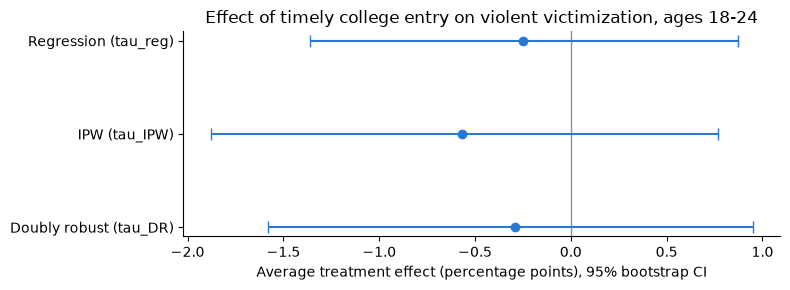

In [9]:
results = pd.DataFrame({
    'E[Y(1)] (%)': 100 * estimates['E[Y(1)]'],
    'E[Y(0)] (%)': 100 * estimates['E[Y(0)]'],
    'ATE (pp)': 100 * estimates['ATE'],
    'bootstrap SE (pp)': 100 * boot.std(axis=0, ddof=1),
    '95% CI low (pp)': 100 * np.percentile(boot, 2.5, axis=0),
    '95% CI high (pp)': 100 * np.percentile(boot, 97.5, axis=0),
}, index=estimates.index).round(2)
display(results)
results.index.name = 'estimator'
results.to_csv(FOLDER / 'ate_results.csv')
print('Saved', FOLDER / 'ate_results.csv')

fig, ax = plt.subplots(figsize=(8, 3))
ypos = np.arange(len(results))[::-1]
ax.axvline(0, color='#8a8f96', lw=1)
ax.errorbar(results['ATE (pp)'], ypos,
            xerr=[results['ATE (pp)'] - results['95% CI low (pp)'], results['95% CI high (pp)'] - results['ATE (pp)']],
            fmt='o', color='#2a78d6', capsize=4)
ax.set_yticks(ypos, results.index)
ax.set(xlabel='Average treatment effect (percentage points), 95% bootstrap CI',
       title='Effect of timely college entry on violent victimization, ages 18-24')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
